## **Data analysis for blinkit**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


import raw data


In [6]:
df=pd.read_csv("blinkit_data.csv")

In [7]:
# top ten row
df.head(10)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
0,Regular,FDX32,Fruits and Vegetables,2012,OUT049,Tier 1,Medium,Supermarket Type1,0.100014,15.10,145.4786,5.0
1,Low Fat,NCB42,Health and Hygiene,2022,OUT018,Tier 3,Medium,Supermarket Type2,0.008596,11.80,115.3492,5.0
2,Regular,FDR28,Frozen Foods,2010,OUT046,Tier 1,Small,Supermarket Type1,0.025896,13.85,165.0210,5.0
3,Regular,FDL50,Canned,2000,OUT013,Tier 3,High,Supermarket Type1,0.042278,12.15,126.5046,5.0
4,Low Fat,DRI25,Soft Drinks,2015,OUT045,Tier 2,Small,Supermarket Type1,0.033970,19.60,55.1614,5.0
5,low fat,FDS52,Frozen Foods,2020,OUT017,Tier 2,Small,Supermarket Type1,0.005505,8.89,102.4016,5.0
6,Low Fat,NCU05,Health and Hygiene,2011,OUT010,Tier 3,Small,Grocery Store,0.098312,11.80,81.4618,5.0
7,Low Fat,NCD30,Household,2015,OUT045,Tier 2,Small,Supermarket Type1,0.026904,19.70,96.0726,5.0
8,Low Fat,FDW20,Fruits and Vegetables,2000,OUT013,Tier 3,High,Supermarket Type1,0.024129,20.75,124.1730,5.0
9,Low Fat,FDX25,Canned,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.101562,NaN,181.9292,5.0


In [8]:
#last 10 rows
df.tail(10)

,Item Fat Content,Item Identifier,Item Type,Outlet Establishment Year,Outlet Identifier,Outlet Location Type,Outlet Size,Outlet Type,Item Visibility,Item Weight,Sales,Rating
8513,Regular,DRY23,Soft Drinks,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.108568,NaN,42.9112,4.0
8514,low fat,FDA11,Baking Goods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.043029,NaN,94.7436,4.0
8515,low fat,FDK38,Canned,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.053032,NaN,149.1734,4.0
8516,low fat,FDO38,Canned,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.072486,NaN,78.9986,4.0
8517,low fat,FDG32,Fruits and Vegetables,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.175143,NaN,222.3772,4.0
8518,low fat,NCT53,Health and Hygiene,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,164.5526,4.0
8519,low fat,FDN09,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.034706,NaN,241.6828,4.0
8520,low fat,DRE13,Soft Drinks,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.027571,NaN,86.6198,4.0
8521,reg,FDT50,Dairy,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.107715,NaN,97.8752,4.0
8522,reg,FDM58,Snack Foods,1998,OUT027,Tier 3,Medium,Supermarket Type3,0.000000,NaN,112.2544,4.0


size of data

In [10]:
df.shape

(8523, 12)

colunm info

In [11]:
df.columns

Index(['Item Fat Content', 'Item Identifier', 'Item Type',
       'Outlet Establishment Year', 'Outlet Identifier',
       'Outlet Location Type', 'Outlet Size', 'Outlet Type', 'Item Visibility',
       'Item Weight', 'Sales', 'Rating'],
      dtype='object')

Data types


In [12]:
df.dtypes

Item Fat Content              object
Item Identifier               object
Item Type                     object
Outlet Establishment Year      int64
Outlet Identifier             object
Outlet Location Type          object
Outlet Size                   object
Outlet Type                   object
Item Visibility              float64
Item Weight                  float64
Sales                        float64
Rating                       float64
dtype: object

Data cleaning

In [13]:
print(df['Item Fat Content'].unique())

['Regular' 'Low Fat' 'low fat' 'LF' 'reg']


see 

lf  is low fat

low fat is also low fat

Low fat is also low fat

and 

regular is reg

In [ ]:
df['Item Fat Content']= df['Item Fat Content'].replace({'LF' : 'Low Fat',
                                                       'Low fat' : 'Low Fat',
                                                       'reg' : 'Regular'})

In [25]:
print(df['Item Fat Content'].unique())

['Regular' 'Low Fat']


Bussiness Requirement

KPI`s Requirement

In [27]:
# total sum
total_sums=df['Sales'].sum()

#avg sales
avg_sales=df['Sales'].mean()

#no of items
no_of_items=df['Sales'].count()

#avg ratings
avg_ratings=df['Rating'].mean()

In [28]:
print(f"total sales : ${total_sums:,.0f}")
print(f"avg sales: ${avg_sales:,.0f}")
print(f"no of items: ${no_of_items:,.0f}")
print(f"avg ratings: ${avg_ratings:,.0f}")

total sales : $1,201,681
avg sales: $141
no of items: $8,523
avg ratings: $4


## **chat Requirements**

total sales by fat content

In [32]:
sales_fat=df.groupby('Item Fat Content')['Sales'].sum()
print(sales_fat)

Item Fat Content
Low Fat    776319.6784
Regular    425361.8024
Name: Sales, dtype: float64


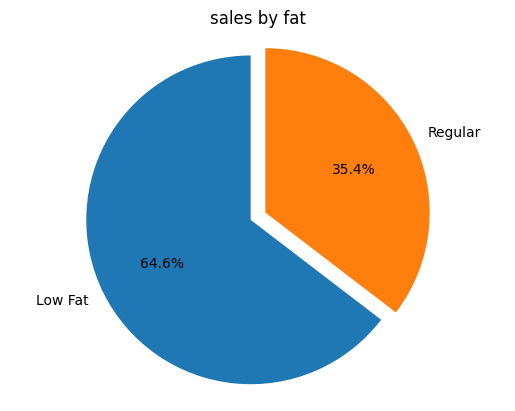

In [38]:
explode = [0.1] + [0]*(len(sales_fat)-1)
plt.pie(sales_fat,labels= sales_fat.index,autopct='%.1f%%',startangle=90 ,explode=explode)
plt.title("sales by fat")
plt.axis('equal')
plt.show()

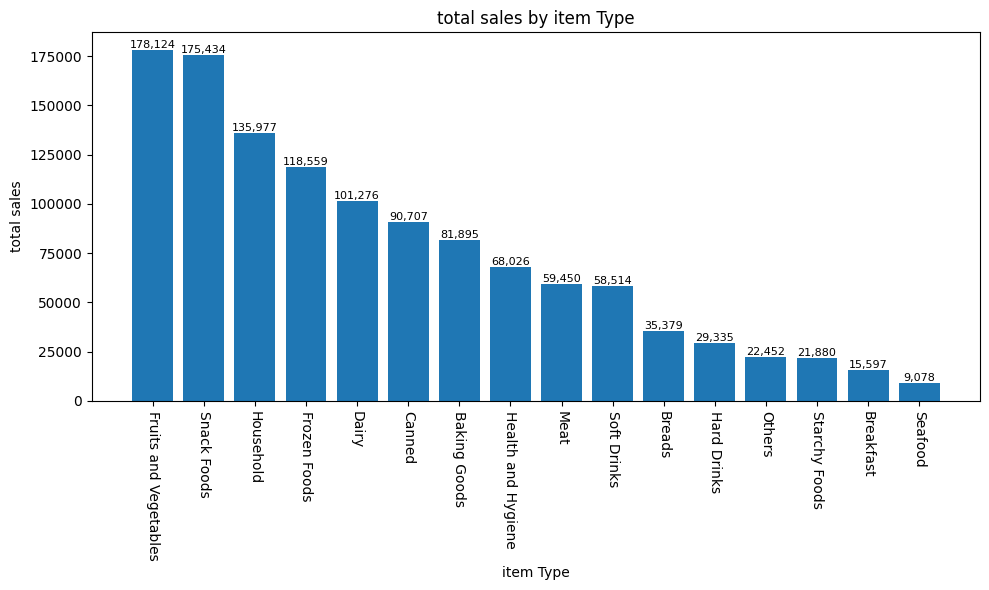

In [42]:
sales_by_type=df.groupby('Item Type')['Sales'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
bars=plt.bar(sales_by_type.index,sales_by_type.values)

plt.xticks(rotation=-90)
plt.xlabel('item Type')
plt.ylabel('total sales')
plt.title('total sales by item Type')

for bar in bars:
    plt.text(bar.get_x() + bar.get_width()/ 2, bar.get_height(),
             f'{bar.get_height():,.0f}' ,  ha='center' , va="bottom" , fontsize=8)
    
plt.tight_layout()
plt.show()

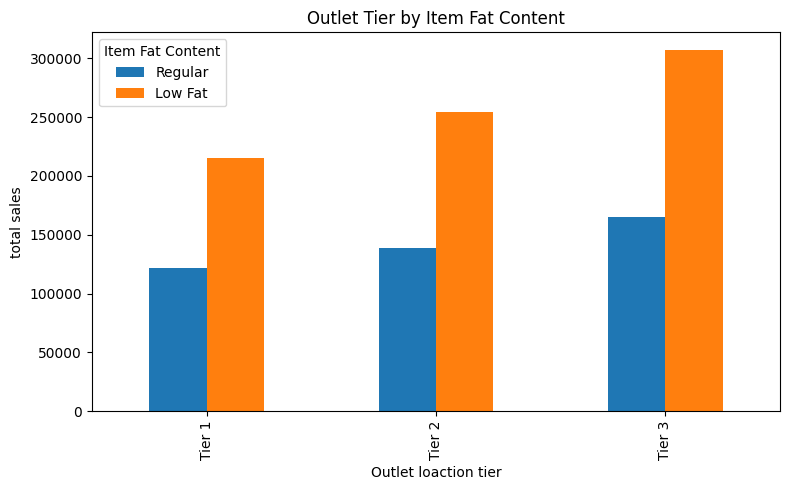

In [44]:
grouped=df.groupby(['Outlet Location Type','Item Fat Content'])['Sales'].sum().unstack()
grouped=grouped[['Regular','Low Fat']]

ax=grouped.plot(kind='bar', figsize=(8,5), title='Outlet Tier by Item Fat Content')
plt.xlabel('Outlet loaction tier')
plt.ylabel('total sales')
plt.legend(title='Item Fat Content')
plt.tight_layout()
plt.show()

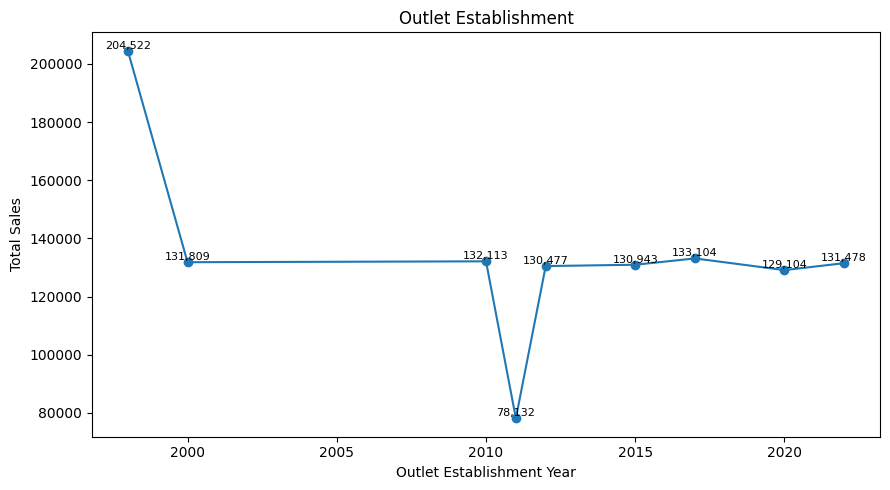

In [47]:
sales_by_year=df.groupby('Outlet Establishment Year')['Sales'].sum().sort_index()
plt.figure(figsize=(9,5))
plt.plot(sales_by_year.index , sales_by_year.values,marker='o',linestyle='-')

plt.xlabel('Outlet Establishment Year')
plt.ylabel('Total Sales')
plt.title('Outlet Establishment')

for x,y in zip(sales_by_year.index,sales_by_year.values):
    plt.text(x,y,f'{y:,.0f}', ha='center' , va='bottom' , fontsize=8)
    
plt.tight_layout()
plt.show()

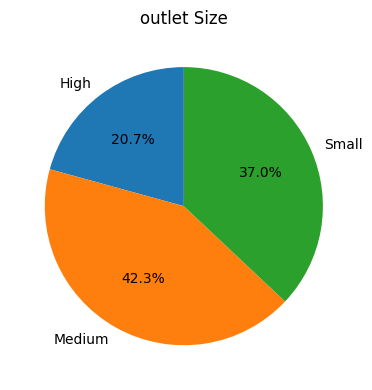

In [51]:
sales_by_outlet=df.groupby('Outlet Size')['Sales'].sum()

plt.figure(figsize=(4,4))
plt.pie(sales_by_outlet,labels=sales_by_outlet.index, autopct='%1.1f%%', startangle=90)
plt.title('outlet Size')
plt.tight_layout()
plt.show()

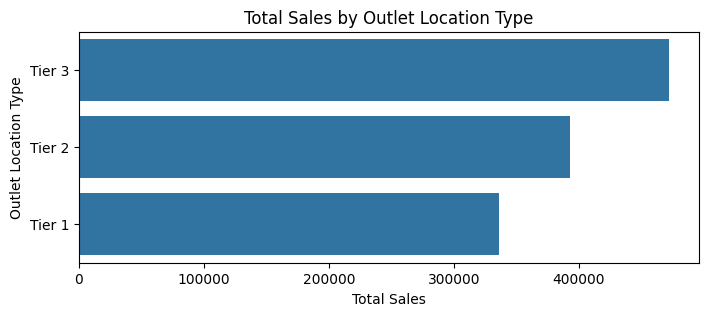

In [52]:
sales_by_location=df.groupby('Outlet Location Type')['Sales'].sum().reset_index()
sales_by_location=sales_by_location.sort_values('Sales',ascending=False)

plt.figure(figsize=(8,3))
ax= sns.barplot(x='Sales',y='Outlet Location Type', data=sales_by_location)
plt.title("Total Sales by Outlet Location Type")
plt.xlabel("Total Sales")
plt.ylabel('Outlet Location Type')
plt.show()